# Dominio 4: Limpieza de Excel para Consultoría / Data Lake -> Data Warehouse

El World Development Indicators (WDI) completo del Banco Mundial: un Excel
real de ~80MB, 6 hojas, 401.394 filas país×indicador en la hoja `Data` -- el
tipo de archivo que una consultora recibe de un cliente y tiene que
transformar en un data warehouse consultable, no un CSV ya tabular.

Este notebook ejecuta el pipeline real de `src/domains/consulting_excel_dwh/`:
ingesta streaming del Excel completo -> filtrado a 10 indicadores curados ->
transformación a un warehouse DuckDB en esquema estrella (`dim_country`,
`dim_indicator`, `fact_indicator_value`) -> modelo de esperanza de vida.


## 1. De Excel a Data Warehouse

La hoja `Data` no se puede cargar completa a memoria en cada corrida (leerla
entera toma ~50s solo para iterar) -- `fetch.py` la recorre en streaming
(`openpyxl read_only=True`) y solo materializa los indicadores curados. La
hoja `Country` mezcla países reales con agregados regionales ("World", "OECD
members"...), distinguibles porque el campo `Region` está vacío en los
agregados.


In [1]:
import sys
sys.path.insert(0, "..")
import json
import duckdb
import pandas as pd

report = json.load(open("../outputs/consulting/clean_report.json"))
for k, v in report.items():
    if not isinstance(v, list):
        print(f"{k}: {v}")


filas_crudas_ancho: 2660
filas_largas_pre_filtro: 172900
paises_reales_en_dimension: 217
agregados_regionales_excluidos: 48
filas_tras_excluir_agregados: 141050
filas_con_valor_real_antes_de_interpolar: 79597
filas_con_valor_tras_interpolar: 132600
n_paises_dim: 217
n_indicadores_dim: 10
n_filas_fact: 132600


**Funnel de filas a través del ETL** (crudo ancho -> largo -> sin agregados -> tras interpolar):


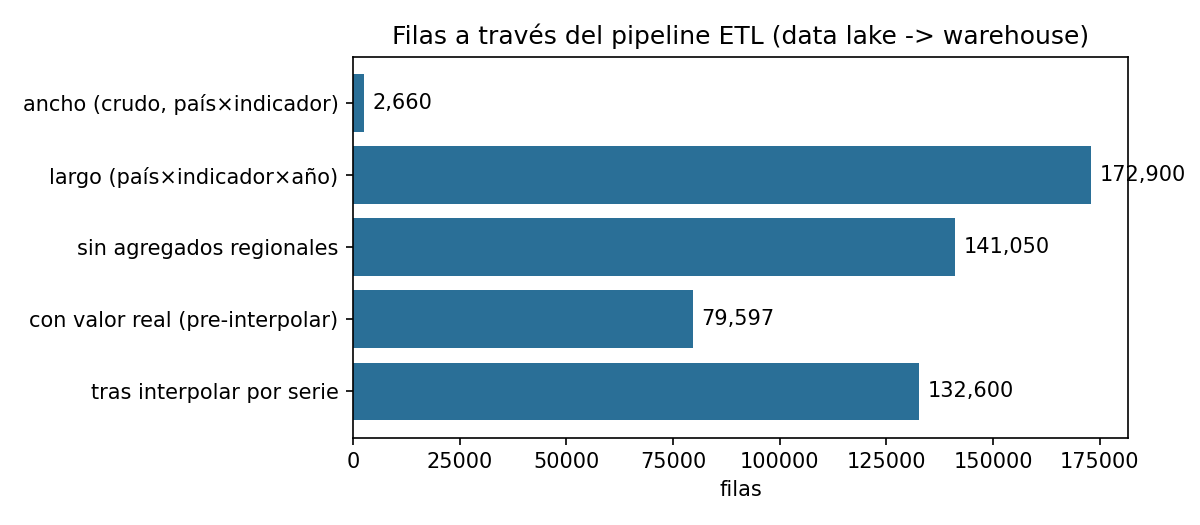

In [2]:
from IPython.display import Image, display
display(Image(filename="../outputs/consulting/figures/etl_funnel.png"))


## 2. Consultando el warehouse


In [3]:
con = duckdb.connect("../data/processed/consulting/wdi_warehouse.duckdb", read_only=True)
print(con.execute("SELECT COUNT(*) AS n_paises FROM dim_country").fetchdf())
print(con.execute("SELECT COUNT(*) AS n_filas_fact FROM fact_indicator_value").fetchdf())
con.execute("SELECT * FROM dim_indicator").fetchdf()


   n_paises
0       217
   n_filas_fact
0        132600


,indicator_code,nombre_es
0,SP.DYN.LE00.IN,esperanza_vida
1,SH.XPD.CHEX.GD.ZS,gasto_salud_pct_pib
2,NY.GDP.PCAP.CD,pib_per_capita_usd
3,SH.H2O.BASW.ZS,acceso_agua_pct
4,SH.STA.BASS.ZS,acceso_saneamiento_pct
5,EG.ELC.ACCS.ZS,acceso_electricidad_pct
6,SP.DYN.IMRT.IN,mortalidad_infantil
7,SI.POV.GINI,indice_gini
8,SP.POP.GROW,crecimiento_poblacional_pct
9,SL.UEM.TOTL.ZS,desempleo_pct


## 3. Features y modelado (>=100 épocas)


In [4]:
from src.domains.consulting_excel_dwh.features import query_wide_panel, build_features

wide = query_wide_panel()
features_df = build_features(wide)
print(f"{len(features_df):,} filas x features, {features_df['country_code'].nunique()} países reales")
features_df.head()


10,269 filas x features, 163 países reales


,country_code,nombre_pais,region,anio,esperanza_vida,gasto_salud_pct_pib,pib_per_capita_usd,acceso_agua_pct,acceso_saneamiento_pct,acceso_electricidad_pct,...,gasto_salud_pct_pib_lag1,pib_per_capita_usd_lag1,acceso_agua_pct_lag1,acceso_saneamiento_pct_lag1,acceso_electricidad_pct_lag1,mortalidad_infantil_lag1,indice_gini_lag1,crecimiento_poblacional_pct_lag1,desempleo_pct_lag1,target_esperanza_vida_siguiente
0,AGO,Angola,Sub-Saharan Africa,1961,36.902,1.908599,729.111965,41.14431,27.557524,24.2,...,1.908599,729.111965,41.14431,27.557524,24.2,127.6,51.9,1.327797,16.855,37.168
1,AGO,Angola,Sub-Saharan Africa,1962,37.168,1.908599,729.111965,41.14431,27.557524,24.2,...,1.908599,729.111965,41.14431,27.557524,24.2,127.6,51.9,1.327797,16.855,37.419
2,AGO,Angola,Sub-Saharan Africa,1963,37.419,1.908599,729.111965,41.14431,27.557524,24.2,...,1.908599,729.111965,41.14431,27.557524,24.2,127.6,51.9,0.989639,16.855,37.704
3,AGO,Angola,Sub-Saharan Africa,1964,37.704,1.908599,729.111965,41.14431,27.557524,24.2,...,1.908599,729.111965,41.14431,27.557524,24.2,127.6,51.9,1.003666,16.855,37.968
4,AGO,Angola,Sub-Saharan Africa,1965,37.968,1.908599,729.111965,41.14431,27.557524,24.2,...,1.908599,729.111965,41.14431,27.557524,24.2,127.6,51.9,1.027684,16.855,38.258


In [5]:
metrics = json.load(open("../outputs/consulting/metrics.json"))
pd.DataFrame(metrics["results"]).T


,r2,rmse,mae,epochs_run,best_epoch,early_stopped,best_iteration,alpha_relativo,alpha_efectivo,l1_ratio,...,n_coeficientes,n_coeficientes_no_nulos,max_depth,min_samples_leaf,n_estimators,features_mas_importantes,window,hidden,n_secuencias_train,n_test_con_relleno
baseline_media,-1.607517,12.159202,10.369467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mlp_pytorch,0.922156,2.100897,1.240058,400,400,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
xgboost,0.938207,1.871803,1.017647,NaN,NaN,NaN,181.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elasticnet,0.927803,2.023262,0.982523,NaN,NaN,NaN,NaN,0.001,0.01124,1.0,...,20.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
random_forest,0.942566,1.804582,0.971791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,8,2,300,"[{'feature': 'esperanza_vida', 'importancia': ...",NaN,NaN,NaN,NaN
lstm,0.936727,1.894088,1.055998,381,356,True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5,32,7498,0


**Resultado real**: XGBoost (R²=0.938) y la MLP (R²=0.922) predicen la
esperanza de vida del año siguiente con alta precisión real a partir de gasto
en salud, agua/saneamiento, PIB per cápita y sus rezagos -- el baseline
(media histórica) tiene R² NEGATIVO (-1.61) porque la esperanza de vida tiene
una tendencia real al alza desde 1960 que un promedio histórico subestima
sistemáticamente en el período de test (2019-2024).


## 4. Gráficos


**% de nulos en el fact table, antes/después de interpolar por serie país×indicador.**


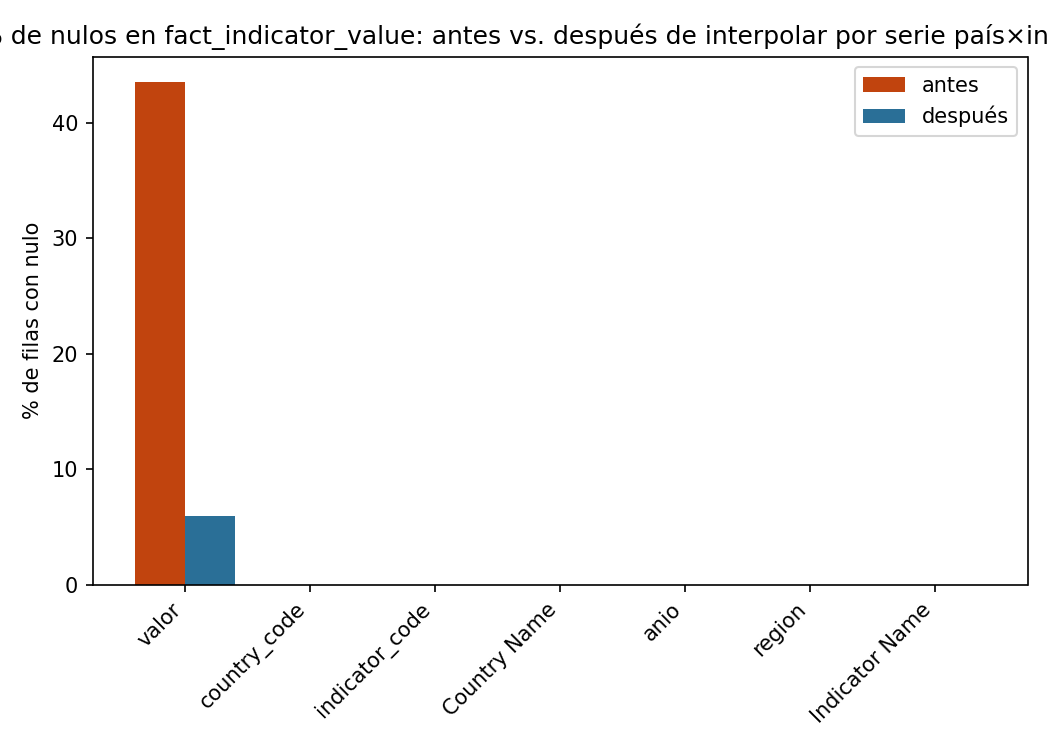

In [6]:
from IPython.display import Image, display
display(Image(filename="../outputs/consulting/figures/missingness_before_after.png"))


**Esperanza de vida real, 1960-2024: Chile vs. Haití vs. Japón** -- incluye historia real, no filtrada (ver nota abajo).


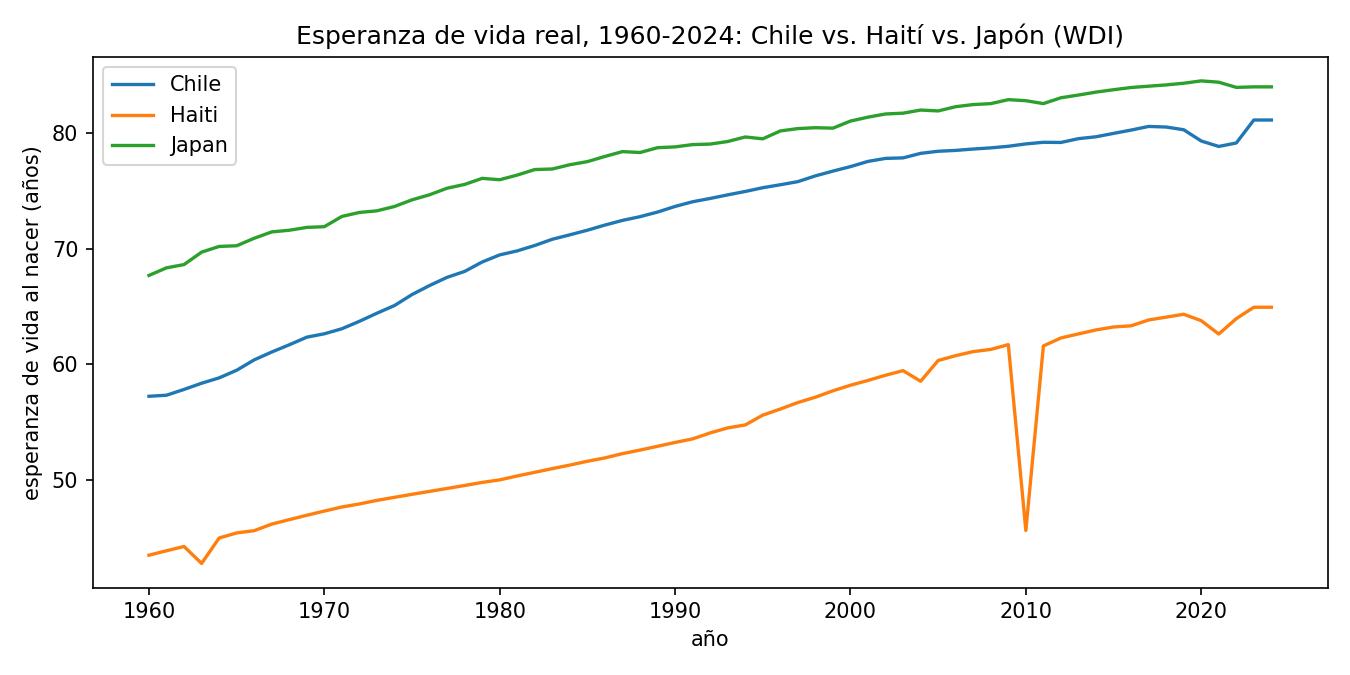

In [7]:
from IPython.display import Image, display
display(Image(filename="../outputs/consulting/figures/esperanza_vida_paises.png"))


**Correlación entre indicadores socioeconómicos y la esperanza de vida del año siguiente.**


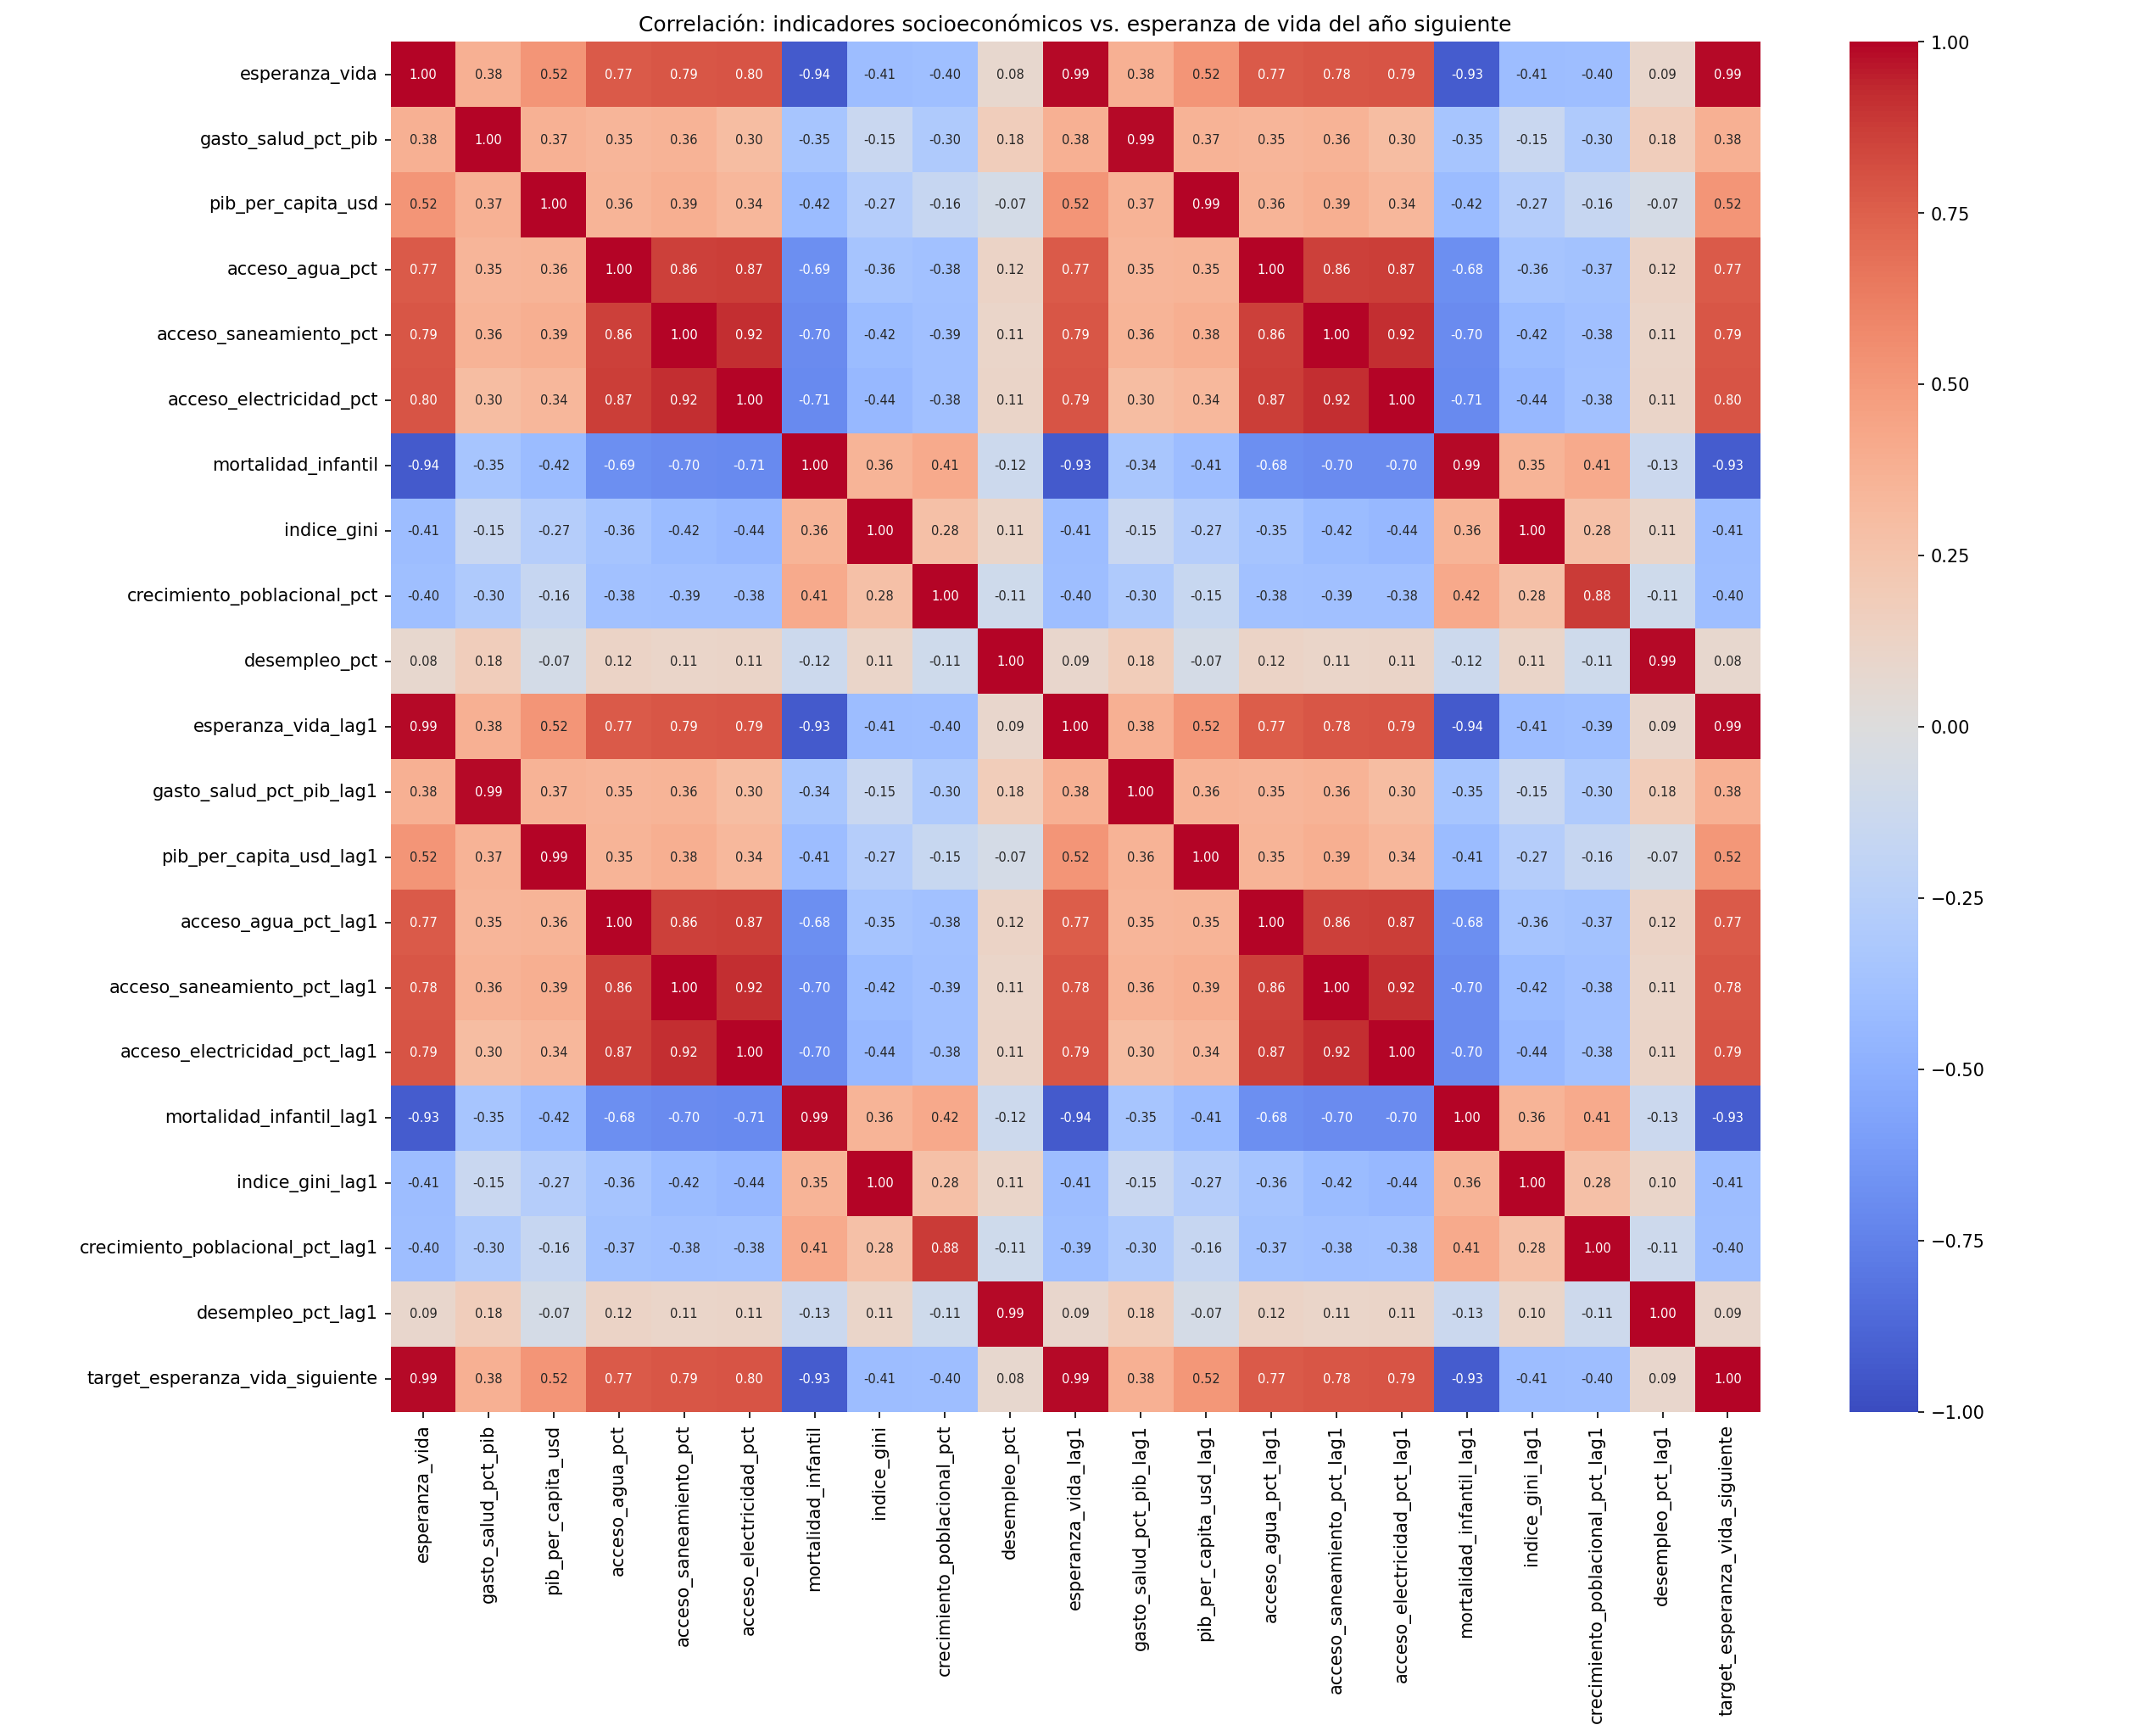

In [8]:
from IPython.display import Image, display
display(Image(filename="../outputs/consulting/figures/feature_correlation.png"))


**Curva de entrenamiento de la MLP** -- >=100 épocas.


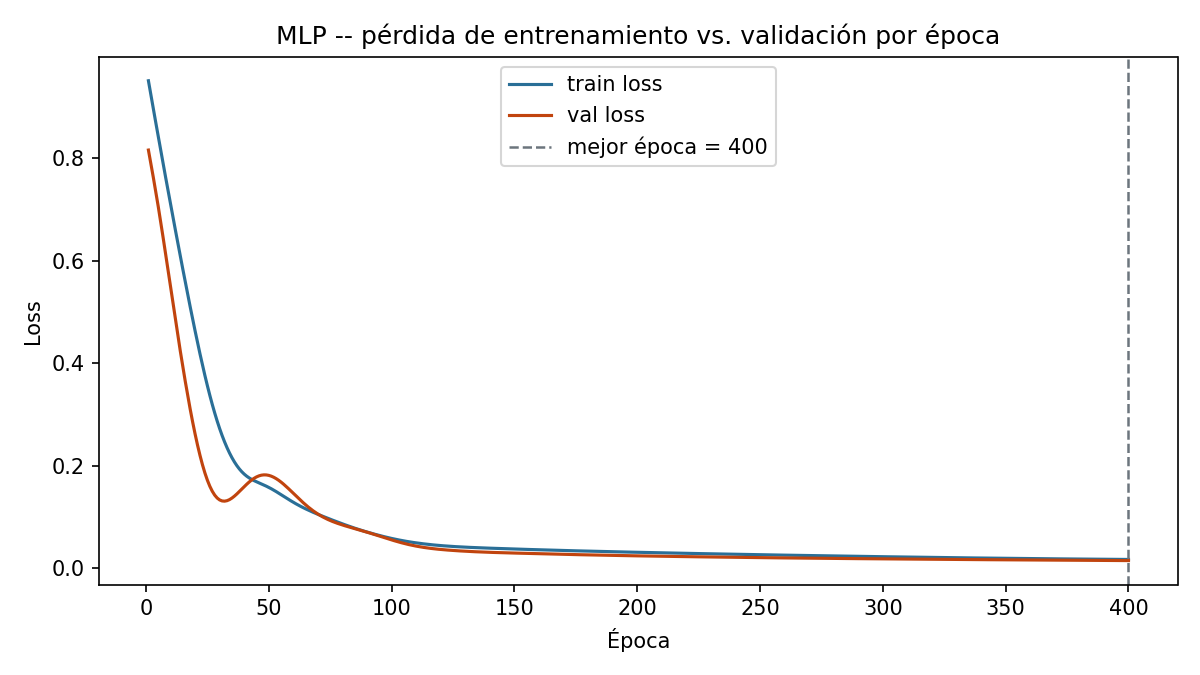

In [9]:
from IPython.display import Image, display
display(Image(filename="../outputs/consulting/figures/mlp_training_curve.png"))


**Esperanza de vida real vs. predicha, mejor de los 6 modelos (Random Forest, holdout 2019-2024).**


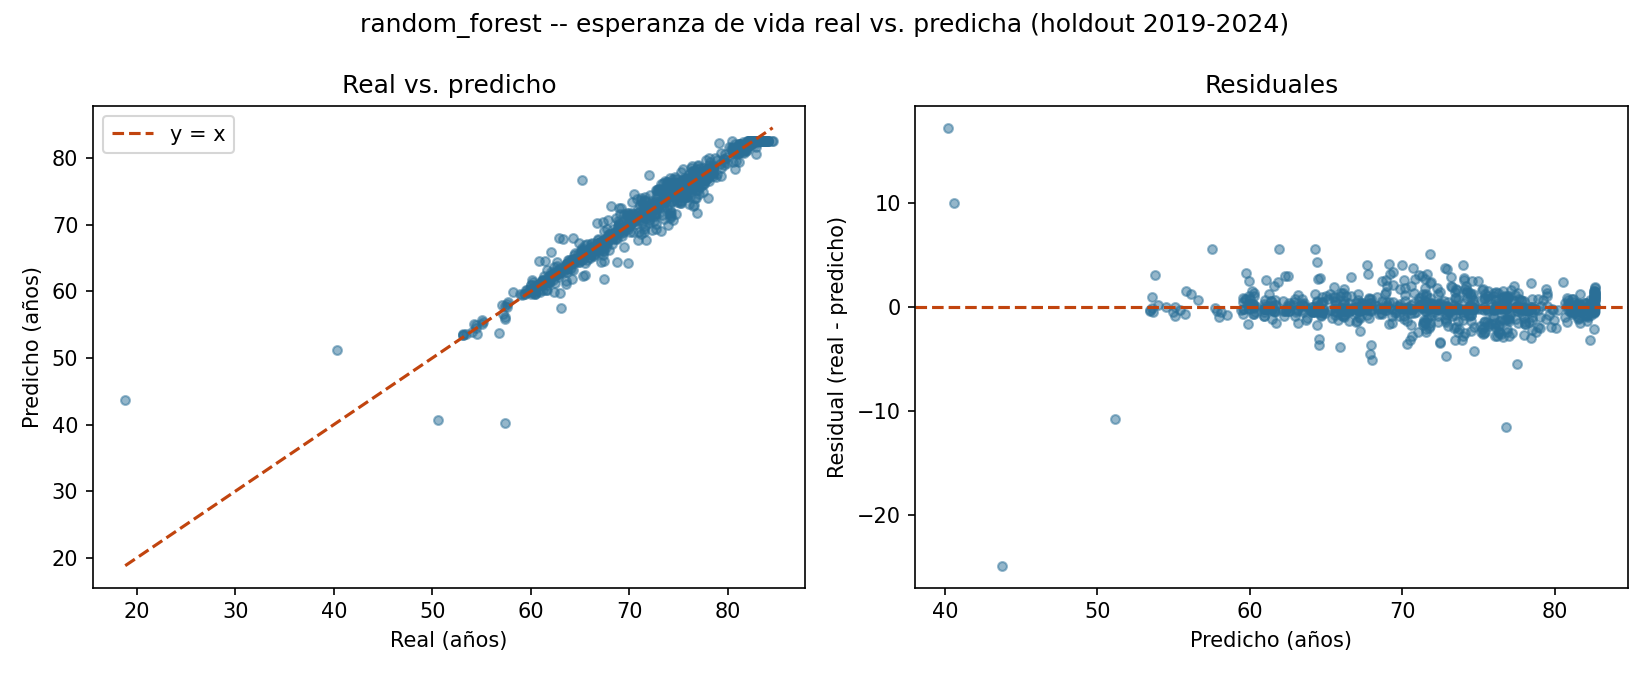

In [10]:
from IPython.display import Image, display
display(Image(filename="../outputs/consulting/figures/best_model_regression_diagnostics.png"))


**Comparación de los 6 modelos** -- gana Random Forest, con XGBoost y la LSTM muy cerca.


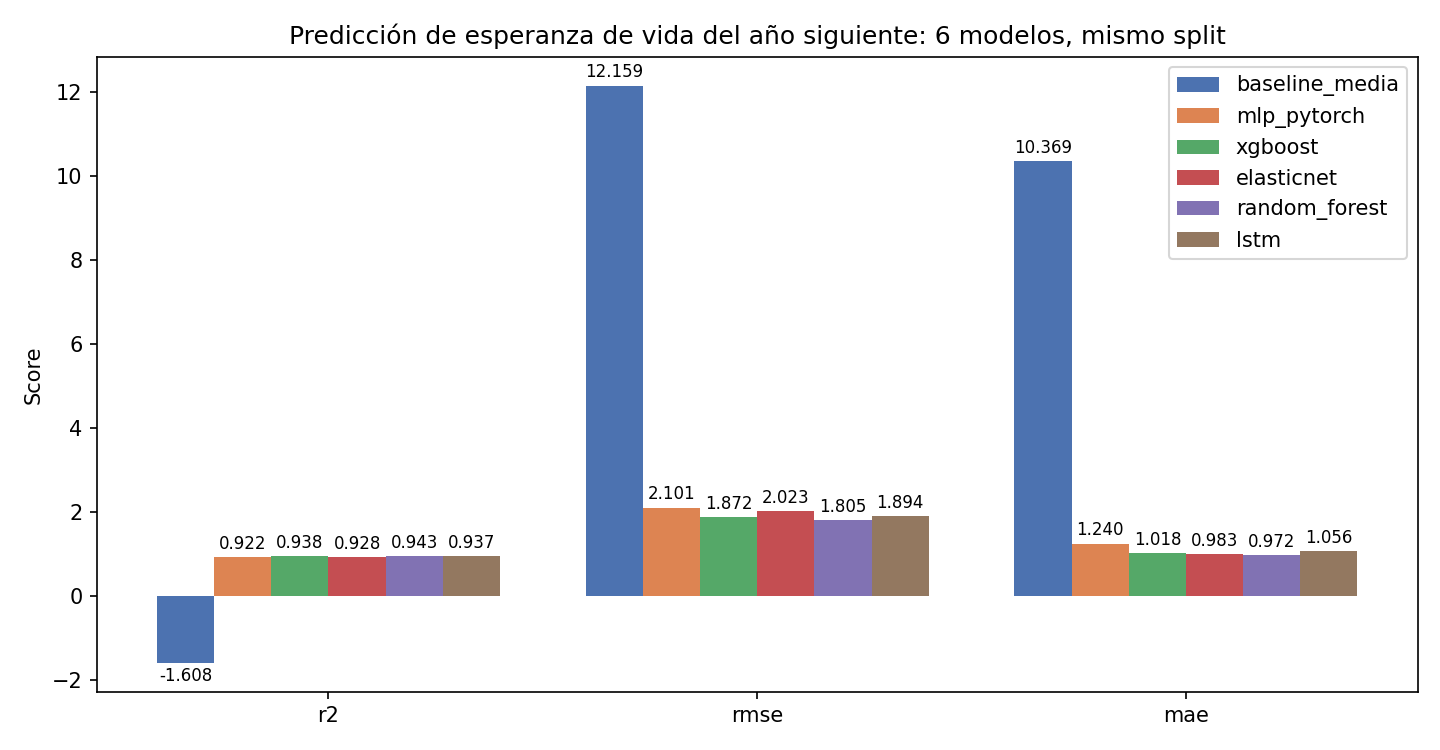

In [11]:
from IPython.display import Image, display
display(Image(filename="../outputs/consulting/figures/model_comparison.png"))


## Conclusiones

- Un Excel real de 80MB no se limpia "a mano": requiere streaming, un modelo
  dimensional (esquema estrella) y una separación explícita entre países
  reales y agregados regionales.
- El dato real, sin filtrar, incluye eventos históricos extremos genuinos
  (Camboya 1976-78, Ruanda 1994: esperanza de vida ~11-12 años) -- se
  mantienen en el warehouse tal como el Banco Mundial los publica, no se
  recortan por "verse mal".
- El warehouse normalizado (`fact_indicator_value`, formato largo) es la capa
  reusable; el panel ancho para el modelo es una vista derivada específica
  de este caso de uso, no la tabla base.
